Initialization paths...
All paths was initialized.
Load 'label' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_label.csv
Load 'tile' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_tile.csv
Loading & preparing image data...

Cropping & loading labels by 1st image:
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/input/images_10m/Sentinel/tiles/39UVV/2020_03_01/comp_s2_90d_b2_l2a_med.frag.0.tif
Files was loaded with shape: (10980, 10980)
Loading from cache...
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/cropped/labels/landcover23c_v571_2020.Samara.tif
Files was loaded with shape: (10980, 10980)
Crop labels is done.

Resizing labels by 1st image:
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/input/images_10m/Sentinel/tiles/39UVV/2020_03_01/comp_s2_90d_b2_l2a_med.frag.0.tif
Files was l

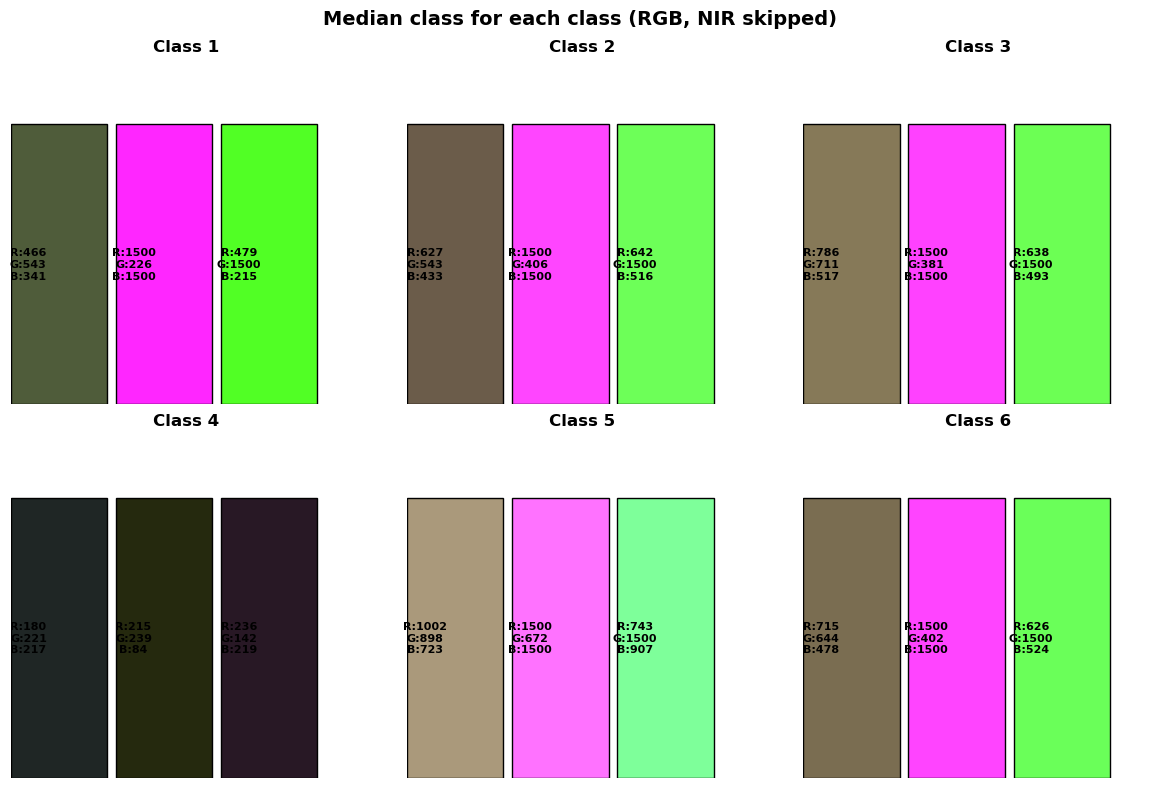

Cosine distance to median sign is calculated. Time: 665.979s
Start stratify. Before output: [1 2 3 4 5 6] [18099412 40047189 28957388  2989742  1341331  1687501]
After: mode: median & stratify True: (array([1, 2, 3, 4, 5, 6], dtype=uint8), array([5000, 5000, 5000, 5000, 5000, 5000]))
Data saved to /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/mask_median_r1_5000_stratified.tif
Mask created.

Zipping dataset by mask...
create tensor by bands
mask: (10980, 10980)
Size dataset before -> after zip by mask:
shape of signs: (30000, 15)
shape of labels: (30000,)
[1 2 3 4 5 6] [5000 5000 5000 5000 5000 5000]


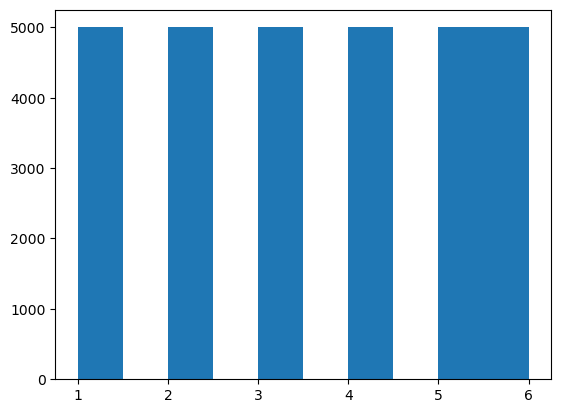

In [1]:
from utils import *
from prepare_ds import *
from train_ml import *
from create_map import *
from validation import *
from visualisation import *

force = False
downgrade_labels = force

if downgrade_labels:
    src = DEFAULT_PATH["labels"]
    out = DEFAULT_PATH["labels"] + "downgraded/"
    classes_matching = DEFAULT_PATH["labels"] + "classes_matching.csv"
    downgrade_classes(src, out, classes_matching)
    DEFAULT_PATH["labels"] = out

# you can use force=True for re-write all caches.
# signs = parse_tifs_from(DEFAULT_PATH["images"], "sign", force=force)
# signs = signs.query("type == 'sign'")

labels = parse_tifs_from(DEFAULT_PATH["labels"], "label", force=force)
labels = labels.query("type == 'label'")

year = 2020
# only_bands = ["r", "b", "g", "n", "swir1", ]
mask_mode = "median"
median_mode = "similar"
# layer_mode = "texture"
# layer_type = "dynamic"
stratify = True
# resize_img = "all_signs"
resize_img = "all_signs"
r = 1
feature_percent = 0.8
count_signs = 5000
percent = None

label = "landcover23c"
labels_paths = labels.query(f"year == {year} and name == '{label}'")

# for 10m low RAM load
only_bands = ["r", "b", "g", "n", "swir1"]
tiles = DEFAULT_PATH["images"] + "tiles/"
tiles = parse_tifs_from(tiles, typeof="tile", force=force)
tiles = (
    tiles.query(f"year == {year} and band in @only_bands")
    .sort_values("band")
    .sort_values("month")
)
signs_paths = tiles

z_x, z_y, x, y, mask = generate_dataset(
    signs_paths,
    labels_paths,
    count_signs,
    percent=percent,
    stratify=stratify,
    resize_img=resize_img,
    mask_mode=mask_mode,
    # layer_mode=layer_mode,
    # layer_type=layer_type,
    r=r,
    median_mode=median_mode,
    feature_percent=feature_percent,
    force=force,
    draw=True,
    verbose=True,
    save_mask=True,
)

uniq_type, uniq_count = np.unique(z_y, return_counts=True)
print(uniq_type, uniq_count)
plt.hist(z_y)
plt.show()

In [2]:
# Module: validation selected px on true
validate_of_select = False

if validate_of_select:
    year = 2020
    map = "wc"
    force = False

    etalon = "/Users/stephenhawking/Coding/ML/low2high_map/data/processing/cropped/etalons/r36000.2020.wc.cor.tif"
    etalon = load_tif(etalon, only_first=True)["array"]

    true = etalon[mask]
    res = z_y
    filled = true > 0
    print(etalon[mask].shape)
    print("Validating cf_report per mode:", mask_mode)
    res = classification_report(true[filled], z_y[filled])
    print(res)

Split X, y -> X_train, y_train...
Start training model...
Selected model / method: RF
Model was trained. Start validate it...

Classification Report:
              precision    recall  f1-score   support

           1       0.82      0.92      0.86       970
           2       0.71      0.79      0.75      1002
           3       0.57      0.67      0.62      1069
           4       0.97      0.89      0.92       938
           5       0.75      0.89      0.81      1000
           6       0.57      0.27      0.37      1021

    accuracy                           0.73      6000
   macro avg       0.73      0.74      0.72      6000
weighted avg       0.72      0.73      0.72      6000

Confusion Matrix:
[[889   1  46   2  12  20]
 [ 22 789 132   0  11  48]
 [ 71 132 715   2  65  84]
 [  6   3  43 831  26  29]
 [  5   7  60   4 893  31]
 [ 96 182 257  21 188 277]]
Saving model...
Model was saved: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/tmp_weights_RF.joblib


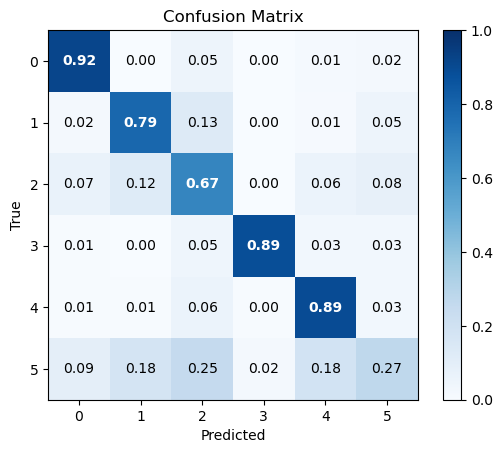

In [3]:
m, m_rep, m_cm, f1 = train_model(z_x, z_y)
plot_confusion(m_cm)

In [4]:
if resize_img == "by_label":
    cache_csv = "test_by_label.csv"
    tiles = parse_tifs_from(
        DEFAULT_PATH["images"] + "tiles/",
        typeof="tile",
        force=False,
        cache_csv=cache_csv,
    )
    tiles = tiles.query(f"year == {year} and band in @only_bands")
    tiles = tiles.sort_values("band").sort_values("month")["path"].tolist()
else:
    tiles = [sign["path"] for sign in x]
    # tiles = [sign["path"] for sign in signs_pathso]

layer_mode = layer_type = None
out = f"handle_10m_{mask_mode}_stratify_{stratify}_f1_{f1:.2f}.tif"
out = DEFAULT_PATH["output"] + out

predicted = create_map(tiles, m, out, layer_mode=layer_mode, layer_type=layer_type)

Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/resized/images/0_10_comp_s2_90d_b2_l2a_med.frag.0.tif
Files was loaded with shape: (10980, 10980)
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/resized/images/1_10_comp_s2_90d_b3_l2a_med.frag.0.tif
Files was loaded with shape: (10980, 10980)
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/resized/images/2_10_comp_s2_90d_b8_l2a_med.frag.0.tif
Files was loaded with shape: (10980, 10980)
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/resized/images/3_10_comp_s2_90d_b4_l2a_med.frag.0.tif
Files was loaded with shape: (10980, 10980)
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/resized/images/4_10_comp_s2_90d_b11_l2a_med.frag.0.tif
Files was loaded with shape: (10980, 10980)
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/resized/images/5_

Creating map...: 100%|██████████| 58/58 [05:44<00:00,  5.95s/it]


Map is done.
Data saved to /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/handle_10m_median_stratify_True_f1_0.72.tif


Load 'etalon' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_etalon.csv
Validating of:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/handle_10m_median_stratify_True_f1_0.72.tif
Etalons will be loaded from cache.
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/cropped/etalons/r36000.2020.wc.cor.tif
Files was loaded with shape: (10980, 10980)
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/handle_10m_median_stratify_True_f1_0.72.tif
Files was loaded with shape: (10980, 10980)
Etalons will be loaded from cache.
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/cropped/etalons/r36000.2020.wc.cor.tif
Files was loaded with shape: (10980, 10980)
(10980, 10980)
Data saved to /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/negative_handle_10m_median_stratify_True_f1_0.72.tif
              precision    rec

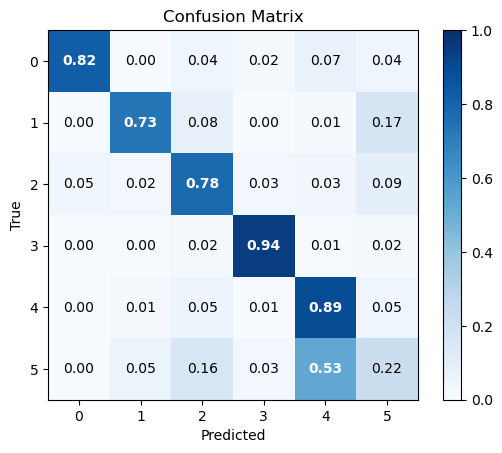

In [5]:
# Module: validation
from validation import *
from visualisation import *

year = 2020
map = "wc"
force = False

etalons = DEFAULT_PATH["etalons"]
etalons = parse_tifs_from(etalons, typeof="etalon", force=force)
etalons = etalons.query(f"year == {year} and map =='{map}'")["path"].to_list()

# predicted = "/Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/handle_10m_secure_stratify_True_f1_0.80.tif"

print("Validating of: ", predicted)
r = validate_how_tif(predicted, etalons, force=force)
# create_diff_map(predicted, etalons, "positive")
create_diff_map(predicted, etalons, "negative")

plot_confusion(r["r36000.2020.wc.cor.tif"]["cf_matrix"])
print(r["r36000.2020.wc.cor.tif"]["report"])